In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP-1 LOAD AND CLEAN DATA

In [2]:
df = pd.read_excel("C:/Users/priya/OneDrive/Desktop/Task-1/Cleaned_Dataset.xlsx")
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1000, 13)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Young Adult (25-34)
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior (50+)
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior (50+)
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior (50+)
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Adult (35-49)


STEP-2 DESCRIPTIVE STATISTICS

In [4]:
print("\n--- Summary Statistics ---")
print(df.describe())
 
print("\n--- Category Counts ---")
print(df['Category'].value_counts())
 
print("\n--- Product Counts ---")
print(df['Product'].value_counts())
 
print("\n--- Gender Counts ---")
print(df['Gender'].value_counts())


--- Summary Statistics ---
                       Order_Date          Age     Quantity    Unit_Price  \
count                        1000  1000.000000  1000.000000   1000.000000   
mean   2025-07-03 11:19:40.800000    41.353000     5.435000  25486.783410   
min           2025-01-01 00:00:00    18.000000     1.000000    145.780000   
25%           2025-03-30 18:00:00    30.000000     3.000000  13895.722500   
50%           2025-07-01 00:00:00    41.000000     5.000000  25398.740000   
75%           2025-10-07 06:00:00    53.000000     8.000000  37512.382500   
max           2026-01-01 00:00:00    65.000000    10.000000  49997.530000   
std                           NaN    13.683626     2.838632  14179.402361   

         Total_Sales  
count    1000.000000  
mean   139399.439650  
min       437.340000  
25%     47066.632500  
50%    108594.025000  
75%    203722.882500  
max    493677.500000  
std    114100.051546  

--- Category Counts ---
Category
Electronics    354
Education      178

 STEP 3: UNIVARIATE ANALYSIS - CHARTS 

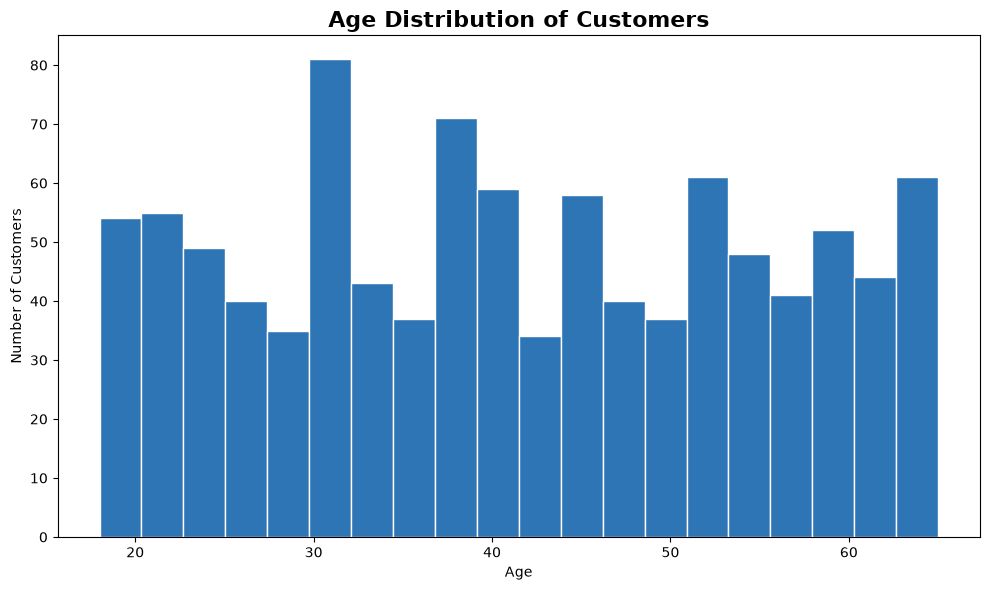

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=20, color='#2E75B6', edgecolor='white')
plt.title('Age Distribution of Customers', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart_age_distribution.png', dpi=150)
plt.show()

Sales by Product

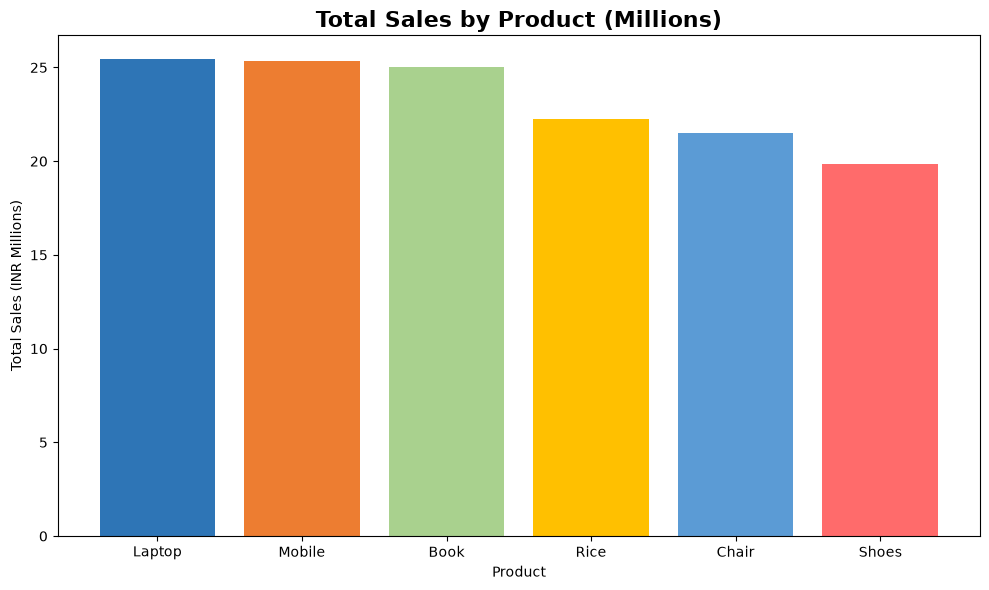

In [6]:
plt.figure(figsize=(10,6))
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)/1e6
plt.bar(product_sales.index, product_sales.values, color=['#2E75B6','#ED7D31','#A9D18E','#FFC000','#5B9BD5','#FF6B6B'])
plt.title('Total Sales by Product (Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Total Sales (INR Millions)')
plt.tight_layout()
plt.savefig('chart_sales_by_product.png', dpi=150)
plt.show()

Sales by Category Pie Chart

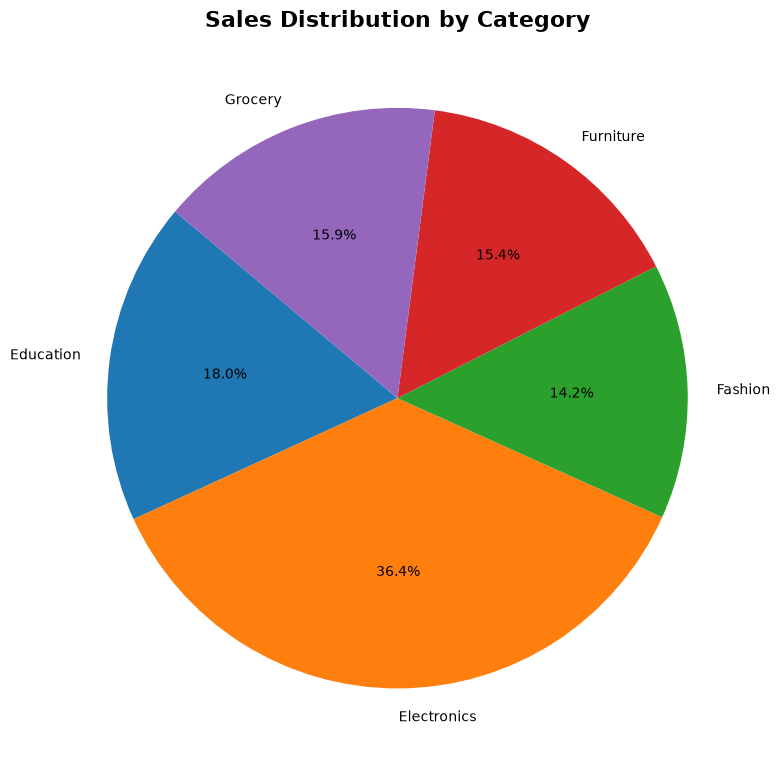

In [7]:
plt.figure(figsize=(8,8))
cat_sales = df.groupby('Category')['Total_Sales'].sum()
plt.pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_sales_by_category.png', dpi=150)
plt.show()
 

Sales by City

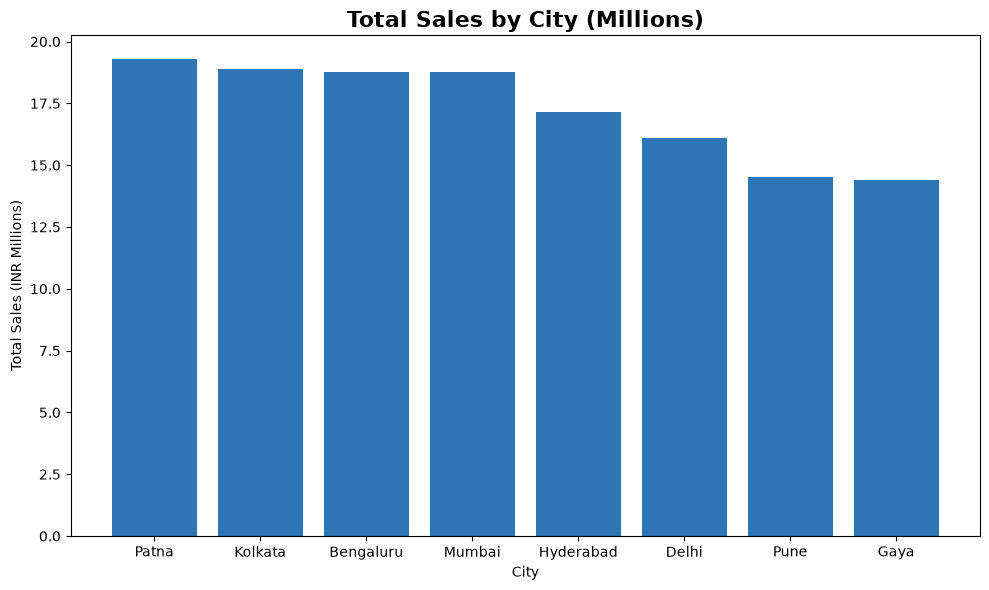

In [9]:
plt.figure(figsize=(10,6))
city_sales = df[df['City']!='Unknown'].groupby('City')['Total_Sales'].sum().sort_values(ascending=False)/1e6
plt.bar(city_sales.index, city_sales.values, color='#2E75B6')
plt.title('Total Sales by City (Millions)', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Sales (INR Millions)')
plt.tight_layout()
plt.savefig('chart_sales_by_city.png', dpi=150)
plt.show()

 Gender Sales

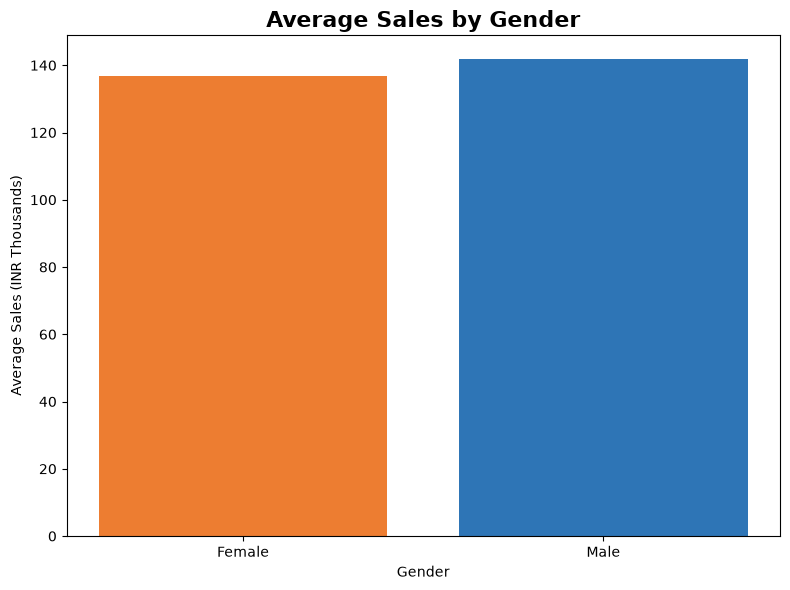

In [10]:
plt.figure(figsize=(8,6))
gender_sales = df.groupby('Gender')['Total_Sales'].mean()
plt.bar(gender_sales.index, gender_sales.values/1000, color=['#ED7D31','#2E75B6'])
plt.title('Average Sales by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Sales (INR Thousands)')
plt.tight_layout()
plt.savefig('chart_gender_sales.png', dpi=150)
plt.show()

STEP 4: MULTIVARIATE ANALYSIS

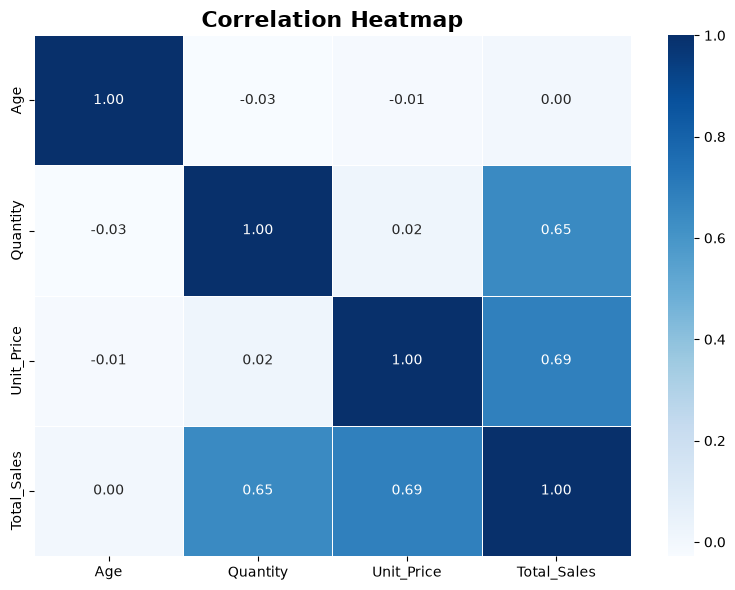

In [11]:
plt.figure(figsize=(8,6))
corr = df[['Age','Quantity','Unit_Price','Total_Sales']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150)
plt.show()

Scatter Plot

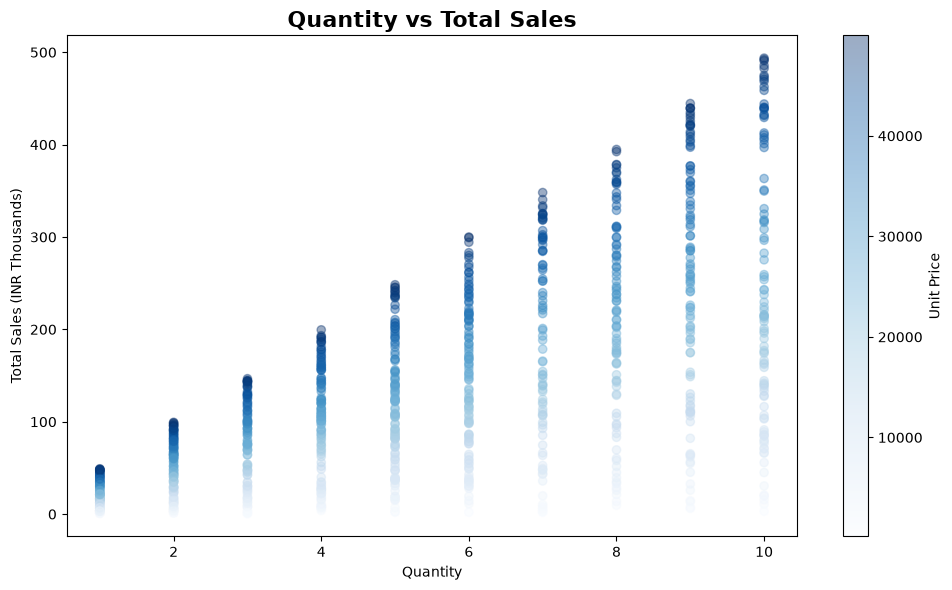

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df['Quantity'], df['Total_Sales']/1000, alpha=0.4, c=df['Unit_Price'], cmap='Blues')
plt.title('Quantity vs Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Quantity')
plt.ylabel('Total Sales (INR Thousands)')
plt.colorbar(label='Unit Price')
plt.tight_layout()
plt.savefig('chart_quantity_vs_sales.png', dpi=150)
plt.show()

Monthly Sales Trend

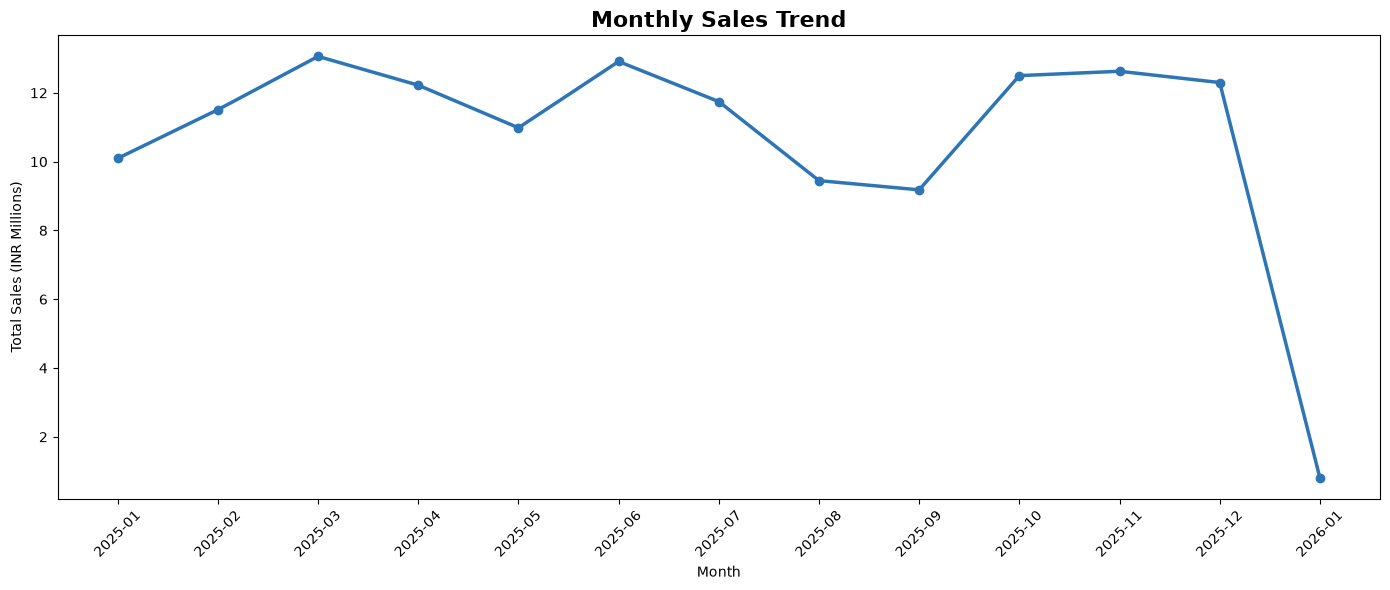

In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
plt.figure(figsize=(14,6))
monthly = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales'].sum()/1e6
plt.plot(monthly.index.astype(str), monthly.values, marker='o', color='#2E75B6', linewidth=2.5)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (INR Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150)
plt.show()

 STEP 6: KEY INSIGHTS

In [14]:
print("\n========== KEY INSIGHTS ==========")
print("Top Product: Laptop (₹2.54 Cr revenue)")
print("Top City: Patna (135 orders)")
print("Top Category: Electronics (36.4% of sales)")
print("Unit Price & Quantity are strongest drivers of sales")
print("Male customers spend slightly more than Female")
print("Fashion & Furniture have lowest sales - growth opportunity")


========== KEY INSIGHTS ==========
Top Product: Laptop (₹2.54 Cr revenue)
Top City: Patna (135 orders)
Top Category: Electronics (36.4% of sales)
Unit Price & Quantity are strongest drivers of sales
Male customers spend slightly more than Female
Fashion & Furniture have lowest sales - growth opportunity
